PART A


FIRST FIVE RECORDS
------------------
   YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1  2020      1                          PWSWN INC    100024   
2  2020      1            RELIABLE CHURCHILL LLLP      1001   
3  2020      1          LANTERNA DISTRIBUTORS INC    100145   
4  2020      1               DIONYSOS IMPORTS INC    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  BOOTLEG RED - 750ML      WINE          0.00   
1            MOMENT DE PLAISIR - 750ML      WINE          0.00   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ      BEER          0.00   
3        SCHLINK HAUS KABINETT - 750ML      WINE          0.00   
4       SANTORINI GAVALA WHITE - 750ML      WINE          0.82   

   RETAIL TRANSFERS  WAREHOUSE SALES  
0               0.0              2.0  
1               1.0              4.0  
2               0.0              1.0  
3               0.0          

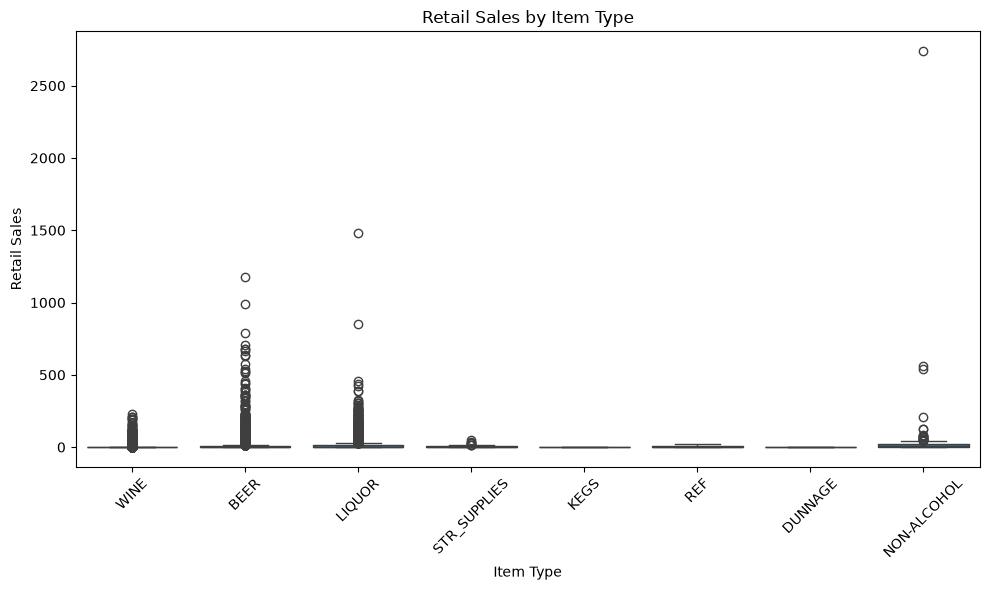


HYPOTHESES
----------
Null Hypothesis (H0):
The average retail sales are equal among all ITEM TYPE categories.

Alternative Hypothesis (H1):
At least one ITEM TYPE has a different average retail sales.

ONE-WAY ANOVA RESULTS
---------------------
F-Statistic : 123.39469052328639
P-Value     : 1.3337307137369178e-179

SIGNIFICANCE TEST
-----------------
Significance Level : 0.05
P-value < 0.05
Decision: Reject the Null Hypothesis.

CONCLUSION
----------
There is a statistically significant difference in average retail sales among the different ITEM TYPE categories.


In [1]:
# Practical 12: Analysis of Variance (ANOVA)
# Part A: One-Way ANOVA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway


# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------

file_name = "Retail and wherehouse Sale.csv"

df = pd.read_csv(file_name)


# --------------------------------------------------
# 2. Display First Five Records
# --------------------------------------------------

print("\nFIRST FIVE RECORDS")
print("------------------")

print(df.head())

print("\nNumber of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])


# --------------------------------------------------
# 3. Display Column Names and Data Types
# --------------------------------------------------

print("\nCOLUMN NAMES")
print("------------")

print(df.columns.tolist())

print("\nDATA TYPES")
print("----------")

print(df.dtypes)


# --------------------------------------------------
# 4. Check Missing Values and Duplicate Records
# --------------------------------------------------

print("\nMISSING VALUES")
print("--------------")

print(df.isnull().sum())

print("\nDUPLICATE RECORDS")
print("-----------------")

print(df.duplicated().sum())


# --------------------------------------------------
# Handle Missing Values in RETAIL SALES
# --------------------------------------------------

df["RETAIL SALES"] = df["RETAIL SALES"].fillna(
    df["RETAIL SALES"].median()
)


# --------------------------------------------------
# 5. Display Different ITEM TYPE Categories
# --------------------------------------------------

print("\nITEM TYPE CATEGORIES")
print("--------------------")

print(df["ITEM TYPE"].unique())


# --------------------------------------------------
# 6. Average RETAIL SALES for Each ITEM TYPE
# --------------------------------------------------

print("\nAVERAGE RETAIL SALES BY ITEM TYPE")
print("---------------------------------")

average_sales = (
    df.groupby("ITEM TYPE")["RETAIL SALES"]
    .mean()
    .sort_values(ascending=False)
)

print(average_sales)


# --------------------------------------------------
# 7. Create Box Plot
# --------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="ITEM TYPE",
    y="RETAIL SALES"
)

plt.title("Retail Sales by Item Type")

plt.xlabel("Item Type")
plt.ylabel("Retail Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# --------------------------------------------------
# 8. Formulate Hypotheses
# --------------------------------------------------

print("\nHYPOTHESES")
print("----------")

print("Null Hypothesis (H0):")
print(
    "The average retail sales are equal "
    "among all ITEM TYPE categories."
)

print("\nAlternative Hypothesis (H1):")
print(
    "At least one ITEM TYPE has a different "
    "average retail sales."
)


# --------------------------------------------------
# 9. Perform One-Way ANOVA
# --------------------------------------------------

groups = []

for item_type in df["ITEM TYPE"].unique():

    group = df[
        df["ITEM TYPE"] == item_type
    ]["RETAIL SALES"]

    groups.append(group)


f_statistic, p_value = f_oneway(*groups)


# --------------------------------------------------
# 10. Display F-Statistic and P-Value
# --------------------------------------------------

print("\nONE-WAY ANOVA RESULTS")
print("---------------------")

print("F-Statistic :", f_statistic)
print("P-Value     :", p_value)


# --------------------------------------------------
# 11 & 12. Compare with Significance Level
# --------------------------------------------------

alpha = 0.05

print("\nSIGNIFICANCE TEST")
print("-----------------")

print("Significance Level :", alpha)

if p_value < alpha:

    print("P-value < 0.05")

    print(
        "Decision: Reject the Null Hypothesis."
    )

else:

    print("P-value >= 0.05")

    print(
        "Decision: Do Not Reject the Null Hypothesis."
    )


# --------------------------------------------------
# 13. Conclusion
# --------------------------------------------------

print("\nCONCLUSION")
print("----------")

if p_value < alpha:

    print(
        "There is a statistically significant difference "
        "in average retail sales among the different "
        "ITEM TYPE categories."
    )

else:

    print(
        "There is no statistically significant difference "
        "in average retail sales among the different "
        "ITEM TYPE categories."
    )

PART B


FACTORIAL EXPERIMENT

Factor 1 : ITEM TYPE
Factor 2 : YEAR
Response : RETAIL SALES

YEAR VALUES
-----------
[2020]

Number of different years: 1

AVERAGE RETAIL SALES
ITEM TYPE AND YEAR
      ITEM TYPE  YEAR  RETAIL SALES
0          BEER  2020     14.118748
1       DUNNAGE  2020      0.000000
2          KEGS  2020      0.000000
3        LIQUOR  2020     13.635171
4   NON-ALCOHOL  2020     31.596204
5           REF  2020      5.783750
6  STR_SUPPLIES  2020      5.485714
7          WINE  2020      3.195334


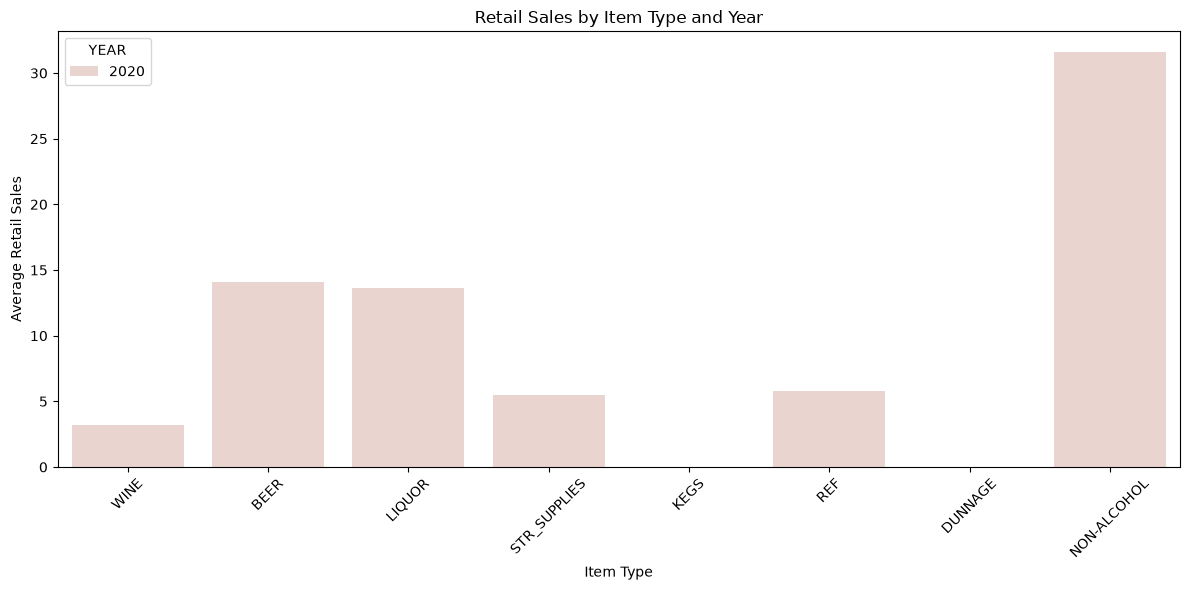


MAIN EFFECT OF ITEM TYPE
ITEM TYPE
BEER            14.118748
DUNNAGE          0.000000
KEGS             0.000000
LIQUOR          13.635171
NON-ALCOHOL     31.596204
REF              5.783750
STR_SUPPLIES     5.485714
WINE             3.195334
Name: RETAIL SALES, dtype: float64

MAIN EFFECT OF YEAR
YEAR
2020    6.93957
Name: RETAIL SALES, dtype: float64

FACTORIAL ANOVA

WARNING
-------
The YEAR column contains only one unique value:
[2020]

Therefore, a two-factor ANOVA cannot be performed.

Reason:
YEAR must contain at least two different levels to calculate its main effect and interaction.

Cannot statistically calculate:
1. Main effect of YEAR
2. ITEM TYPE × YEAR interaction

The ITEM TYPE effect has already been tested using one-way ANOVA in Part A.

FINAL BUSINESS CONCLUSION
The uploaded dataset contains only one year, 2020.
Therefore, a complete factorial experiment using ITEM TYPE and YEAR cannot be performed.
A dataset containing at least two different years is required to tes

In [12]:
# Practical 12: Factorial Experiment
# Part B: Factorial ANOVA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols


# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------

file_name = "Retail and wherehouse Sale.csv"

df = pd.read_csv(file_name)


# --------------------------------------------------
# Handle Missing RETAIL SALES
# --------------------------------------------------

df["RETAIL SALES"] = df["RETAIL SALES"].fillna(
    df["RETAIL SALES"].median()
)


# --------------------------------------------------
# 14. Select ITEM TYPE and YEAR as Factors
# --------------------------------------------------

print("\nFACTORIAL EXPERIMENT")
print("====================")

print("\nFactor 1 : ITEM TYPE")
print("Factor 2 : YEAR")
print("Response : RETAIL SALES")


# --------------------------------------------------
# Check YEAR Values
# --------------------------------------------------

print("\nYEAR VALUES")
print("-----------")

print(df["YEAR"].unique())

print(
    "\nNumber of different years:",
    df["YEAR"].nunique()
)


# --------------------------------------------------
# 15. Average RETAIL SALES for Each Combination
# --------------------------------------------------

print("\nAVERAGE RETAIL SALES")
print("ITEM TYPE AND YEAR")
print("===================")

average_sales = (
    df.groupby(
        ["ITEM TYPE", "YEAR"]
    )["RETAIL SALES"]
    .mean()
    .reset_index()
)

print(average_sales)


# --------------------------------------------------
# 16. Visualization
# --------------------------------------------------

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="ITEM TYPE",
    y="RETAIL SALES",
    hue="YEAR",
    errorbar=None
)

plt.title(
    "Retail Sales by Item Type and Year"
)

plt.xlabel("Item Type")
plt.ylabel("Average Retail Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# --------------------------------------------------
# 17. Main Effect of ITEM TYPE
# --------------------------------------------------

print("\nMAIN EFFECT OF ITEM TYPE")
print("========================")

item_type_effect = (
    df.groupby("ITEM TYPE")["RETAIL SALES"]
    .mean()
)

print(item_type_effect)


# --------------------------------------------------
# 18. Main Effect of YEAR
# --------------------------------------------------

print("\nMAIN EFFECT OF YEAR")
print("===================")

year_effect = (
    df.groupby("YEAR")["RETAIL SALES"]
    .mean()
)

print(year_effect)


# --------------------------------------------------
# 19 & 20. Factorial ANOVA
# --------------------------------------------------

print("\nFACTORIAL ANOVA")
print("===============")


# Check whether YEAR has at least two levels

if df["YEAR"].nunique() < 2:

    print("\nWARNING")
    print("-------")

    print(
        "The YEAR column contains only one unique value:"
    )

    print(df["YEAR"].unique())

    print("\nTherefore, a two-factor ANOVA cannot be performed.")

    print("\nReason:")

    print(
        "YEAR must contain at least two different levels "
        "to calculate its main effect and interaction."
    )

    print("\nCannot statistically calculate:")

    print("1. Main effect of YEAR")
    print("2. ITEM TYPE × YEAR interaction")

    print(
        "\nThe ITEM TYPE effect has already been tested "
        "using one-way ANOVA in Part A."
    )


else:

    # --------------------------------------------------
    # Perform Factorial ANOVA
    # --------------------------------------------------

    model = ols(
        "Q('RETAIL SALES') ~ "
        "C(Q('ITEM TYPE')) * C(Q('YEAR'))",
        data=df
    ).fit()

    anova_table = sm.stats.anova_lm(
        model,
        typ=2
    )


    # --------------------------------------------------
    # 21. Display Statistical Results
    # --------------------------------------------------

    print("\nANOVA TABLE")
    print("-----------")

    print(anova_table)

    print("\nP-VALUES")
    print("--------")

    print(anova_table["PR(>F)"])


    # --------------------------------------------------
    # 22. Identify Significant Effects
    # --------------------------------------------------

    print("\nSIGNIFICANT EFFECTS")
    print("-------------------")

    for effect, p_value in anova_table["PR(>F)"].items():

        if pd.notna(p_value):

            if p_value < 0.05:

                print(
                    effect,
                    ": Significant"
                )

            else:

                print(
                    effect,
                    ": Not Significant"
                )


# --------------------------------------------------
# 23. Final Business Conclusion
# --------------------------------------------------

print("\nFINAL BUSINESS CONCLUSION")
print("=========================")

if df["YEAR"].nunique() < 2:

    print(
        "The uploaded dataset contains only one year, 2020."
    )

    print(
        "Therefore, a complete factorial experiment using "
        "ITEM TYPE and YEAR cannot be performed."
    )

    print(
        "A dataset containing at least two different years "
        "is required to test the YEAR effect and the "
        "ITEM TYPE × YEAR interaction."
    )

else:

    print(
        "The factorial ANOVA results can be used to determine "
        "the significant effects of ITEM TYPE, YEAR, and "
        "their interaction."
    )